# EDA — Comportamiento financiero ECF 2021

**Objetivo del análisis**

Analizar el comportamiento financiero de la población española en 2021 usando la Encuesta de Competencias Financieras del Banco de España.

> ¿Qué productos financieros tiene, adquiere o utiliza la población, y cómo puede ajustarse la estrategia de negocio bancaria?


## 1. Carga de datos

In [25]:
import pandas as pd
import matplotlib.pyplot as plt


# Carga del archivo original
# Ajusta la ruta solo si tu archivo está en otra carpeta
datos = pd.read_csv("../../Data/ecf_data_original_260511.csv")

datos.info()
datos.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7179 entries, 0 to 7178
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   concepto       7179 non-null   object 
 1   elemento       7179 non-null   object 
 2   estadistico    7179 non-null   object 
 3   desglose       7179 non-null   object 
 4   categoria      7179 non-null   object 
 5   unidadMedida   7179 non-null   object 
 6   ola            7179 non-null   int64  
 7   valor          7179 non-null   float64
 8   errorEstandar  7179 non-null   int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 504.9+ KB


,concepto,elemento,estadistico,desglose,categoria,unidadMedida,ola,valor,errorEstandar
0,CONOCIMIENTOS FINANCIEROS,INFLACION_CORRECTAS,PORCENTAJE DE RESPUESTAS,Todos los individuos,Todos los individuos,%,2016,58.200859,0
1,CONOCIMIENTOS FINANCIEROS,INFLACION_INCORRECTAS,PORCENTAJE DE RESPUESTAS,Todos los individuos,Todos los individuos,%,2016,32.661572,0
2,CONOCIMIENTOS FINANCIEROS,INFLACION_NO SABE,PORCENTAJE DE RESPUESTAS,Todos los individuos,Todos los individuos,%,2016,8.924821,0
3,CONOCIMIENTOS FINANCIEROS,TIPO INTERES COMPUESTO_CORRECTAS,PORCENTAJE DE RESPUESTAS,Todos los individuos,Todos los individuos,%,2016,45.685558,0
4,CONOCIMIENTOS FINANCIEROS,TIPO INTERES COMPUESTO_INCORRECTAS,PORCENTAJE DE RESPUESTAS,Todos los individuos,Todos los individuos,%,2016,43.677711,0


In [26]:
import os

print(os.getcwd())

/Users/fedecrs/ProjecteData/Equip_27/Scripts/260511


In [27]:
print(os.listdir())

['.DS_Store', 'comportamiento_financiero_260511.ipynb']


## 2. Limpieza básica

El archivo ya viene bastante estructurado, por lo que solo hacemos una limpieza mínima:

- Normalizar nombres de columnas.
- Limpiar espacios en textos.
- Convertir `ola`, `valor` y `error_estandar` a formato numérico.


In [28]:
# Normalizar nombres de columnas
datos.columns = (
    datos.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# Renombrar columnas para facilitar el uso
datos = datos.rename(columns={
    'unidadmedida': 'unidad_medida',
    'errorestandar': 'error_estandar'
})

# Limpiar columnas de texto
columnas_texto = ['concepto', 'elemento', 'estadistico', 'desglose', 'categoria', 'unidad_medida']

for col in columnas_texto:
    datos[col] = datos[col].astype(str).str.strip()

# Convertir columnas numéricas
datos['ola'] = pd.to_numeric(datos['ola'], errors='coerce')
datos['valor'] = pd.to_numeric(datos['valor'], errors='coerce')
datos['error_estandar'] = pd.to_numeric(datos['error_estandar'], errors='coerce')

print('Filas y columnas:', datos.shape)
print('Duplicados exactos:', datos.duplicated().sum())
print('Nulos por columna:')
datos.isna().sum()


Filas y columnas: (7179, 9)
Duplicados exactos: 0
Nulos por columna:


concepto          0
elemento          0
estadistico       0
desglose          0
categoria         0
unidad_medida     0
ola               0
valor             0
error_estandar    0
dtype: int64

## 3. Filtrar solo comportamiento financiero 2021

Nos quedamos únicamente con la ola 2021 y con los bloques relacionados con comportamiento financiero.


In [29]:
bloques_comportamiento = [
    'TENENCIA DE PRODUCTOS FINANCIEROS',
    'ADQUISICION DE PRODUCTOS FINANCIEROS',
    'VEHICULOS DE AHORRO',
    'ACCESO AL CREDITO',
    'GASTOS MAYORES QUE INGRESOS',
    'VULNERABILIDAD ECONOMICA'
]

comportamiento = datos[
    (datos['ola'] == 2021) &
    (datos['concepto'].isin(bloques_comportamiento))
].copy()

print('Dataset comportamiento financiero 2021:', comportamiento.shape)
comportamiento.head()


Dataset comportamiento financiero 2021: (2475, 9)


,concepto,elemento,estadistico,desglose,categoria,unidad_medida,ola,valor,error_estandar
3084,TENENCIA DE PRODUCTOS FINANCIEROS,TENENCIA PRODUCTO_CUENTA CORRIENTE,PORCENTAJE DE RESPUESTAS,Todos los individuos,Todos los individuos,%,2021,97.990761,0
3085,TENENCIA DE PRODUCTOS FINANCIEROS,TENENCIA PRODUCTO_ALGUN VEHICULO DE AHORRO,PORCENTAJE DE RESPUESTAS,Todos los individuos,Todos los individuos,%,2021,40.777554,0
3086,TENENCIA DE PRODUCTOS FINANCIEROS,TENENCIA PRODUCTO_ALGUN VEHICULO DE AHORRO (SI...,PORCENTAJE DE RESPUESTAS,Todos los individuos,Todos los individuos,%,2021,38.303490,0
3087,TENENCIA DE PRODUCTOS FINANCIEROS,TENENCIA PRODUCTO_CUENTA DE AHORRO,PORCENTAJE DE RESPUESTAS,Todos los individuos,Todos los individuos,%,2021,17.510118,0
3088,TENENCIA DE PRODUCTOS FINANCIEROS,TENENCIA PRODUCTO_PLAN DE PENSIONES,PORCENTAJE DE RESPUESTAS,Todos los individuos,Todos los individuos,%,2021,20.652828,0


## 4. Crear una columna de indicador más legible

In [30]:
def limpiar_indicador(texto):
    reemplazos = [
        'TENENCIA PRODUCTO_',
        'ADQUISICION PRODUCTO_',
        'VEHICULOS AHORRO_',
        'ACCESO CREDITO_',
        'GASTOS MAYORES QUE INGRESOS_',
        'VULNERABILIDAD ECONOMICA_'
    ]
    for r in reemplazos:
        texto = texto.replace(r, '')
    return texto.replace('_', ' ').title()

comportamiento['indicador'] = comportamiento['elemento'].apply(limpiar_indicador)

comportamiento[['concepto', 'indicador', 'desglose', 'categoria', 'valor']].head()


,concepto,indicador,desglose,categoria,valor
3084,TENENCIA DE PRODUCTOS FINANCIEROS,Cuenta Corriente,Todos los individuos,Todos los individuos,97.990761
3085,TENENCIA DE PRODUCTOS FINANCIEROS,Algun Vehiculo De Ahorro,Todos los individuos,Todos los individuos,40.777554
3086,TENENCIA DE PRODUCTOS FINANCIEROS,Algun Vehiculo De Ahorro (Sin Criptomonedas),Todos los individuos,Todos los individuos,38.303490
3087,TENENCIA DE PRODUCTOS FINANCIEROS,Cuenta De Ahorro,Todos los individuos,Todos los individuos,17.510118
3088,TENENCIA DE PRODUCTOS FINANCIEROS,Plan De Pensiones,Todos los individuos,Todos los individuos,20.652828


# Análisis 1 — Visión general de la población

Primero analizamos los resultados generales, sin segmentar por edad, renta o situación laboral. Para eso usamos el desglose `Todos los individuos`.


In [31]:
general = comportamiento[comportamiento['desglose'] == 'Todos los individuos'].copy()

general[['concepto', 'indicador', 'valor']].sort_values(['concepto', 'valor'], ascending=[True, False]).head(20)


,concepto,indicador,valor
6552,ACCESO AL CREDITO,Alguna,7.724787
6549,ACCESO AL CREDITO,Rechazo Total,3.642516
6551,ACCESO AL CREDITO,No Pidieron,2.894107
6550,ACCESO AL CREDITO,Rechazo Cantidad,1.816599
4358,ADQUISICION DE PRODUCTOS FINANCIEROS,Ha Adquirido Alguno De Los Productos,46.930973
4359,ADQUISICION DE PRODUCTOS FINANCIEROS,Ha Adquirido Alguno De Los Productos (Sin Crip...,45.412800
4355,ADQUISICION DE PRODUCTOS FINANCIEROS,Alguna Hipoteca O Prestamo,19.665552
4344,ADQUISICION DE PRODUCTOS FINANCIEROS,Algun Vehiculo De Ahorro,19.517580
4354,ADQUISICION DE PRODUCTOS FINANCIEROS,Tarjeta De Credito,16.907932
4345,ADQUISICION DE PRODUCTOS FINANCIEROS,Algun Vehiculo De Ahorro (Sin Criptomonedas),16.304728


## 1.1 Productos financieros que más tiene la población

,indicador,valor
3084,Cuenta Corriente,97.990761
3095,Tarjeta De Credito,62.781231
3096,Alguna Hipoteca O Prestamo,41.651428
3085,Algun Vehiculo De Ahorro,40.777554
3086,Algun Vehiculo De Ahorro (Sin Criptomonedas),38.303490
3093,Seguro De Vida,30.952272
3097,Hipoteca,29.320559
3094,Seguro Medico,23.629860
3098,Prestamo Personal,21.158237
3088,Plan De Pensiones,20.652828


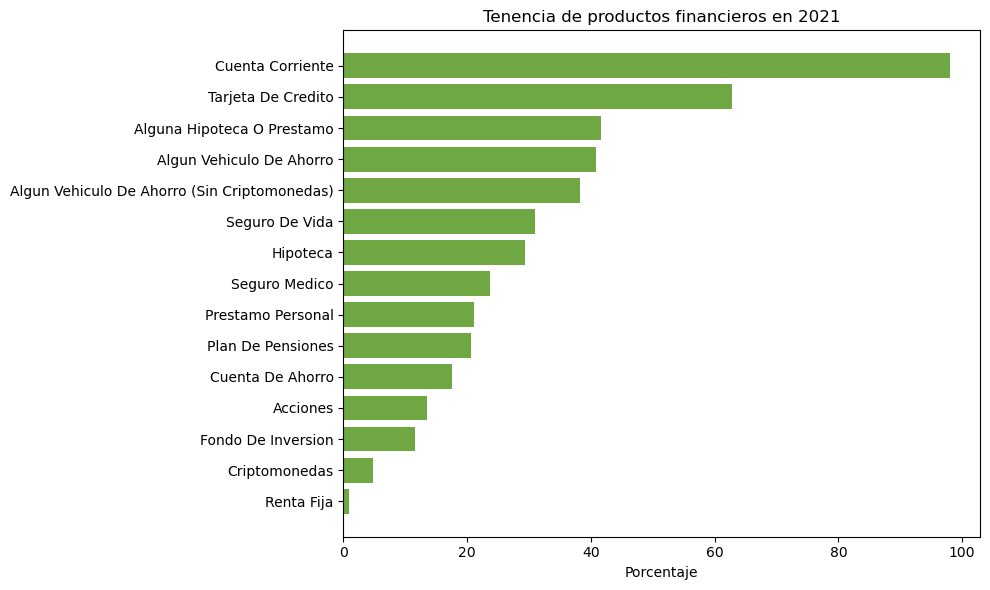

In [32]:
tenencia_general = general[general['concepto'] == 'TENENCIA DE PRODUCTOS FINANCIEROS']

tenencia_general = tenencia_general.sort_values('valor', ascending=False)

display(tenencia_general[['indicador', 'valor']])

plt.figure(figsize=(10, 6))
plt.barh(tenencia_general['indicador'], tenencia_general['valor'], color='#6FA843')
plt.gca().invert_yaxis()
plt.title('Tenencia de productos financieros en 2021')
plt.xlabel('Porcentaje')
plt.tight_layout()
plt.show()


**Lectura de negocio**

- La cuenta corriente es prácticamente universal, por lo que no es una gran oportunidad diferencial.
- La tarjeta de crédito tiene una presencia alta.
- Las hipotecas, préstamos y vehículos de ahorro tienen presencia relevante.
- Productos como fondos de inversión, renta fija o criptomonedas tienen menor penetración, por lo que pueden ser oportunidades de crecimiento según el segmento.


## 1.2 Productos financieros que la población adquiere

,indicador,valor
4358,Ha Adquirido Alguno De Los Productos,46.930973
4359,Ha Adquirido Alguno De Los Productos (Sin Crip...,45.412800
4355,Alguna Hipoteca O Prestamo,19.665552
4344,Algun Vehiculo De Ahorro,19.517580
4354,Tarjeta De Credito,16.907932
4345,Algun Vehiculo De Ahorro (Sin Criptomonedas),16.304728
4357,Prestamo Personal,16.185261
4352,Seguro De Vida,10.543268
4353,Seguro Medico,9.792887
4348,Fondo De Inversion,6.964504


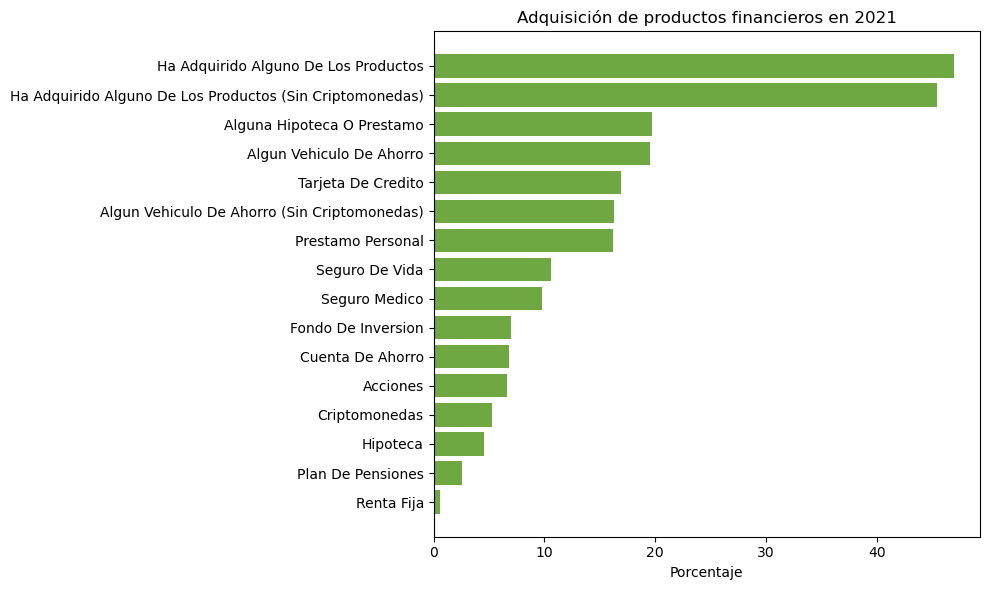

In [33]:
adquisicion_general = general[general['concepto'] == 'ADQUISICION DE PRODUCTOS FINANCIEROS']

adquisicion_general = adquisicion_general.sort_values('valor', ascending=False)

display(adquisicion_general[['indicador', 'valor']])

plt.figure(figsize=(10, 6))
plt.barh(adquisicion_general['indicador'], adquisicion_general['valor'], color='#6FA843')
plt.gca().invert_yaxis()
plt.title('Adquisición de productos financieros en 2021')
plt.xlabel('Porcentaje')
plt.tight_layout()
plt.show()


**Lectura de negocio**

- La adquisición reciente de productos financieros muestra qué productos tienen movimiento comercial.
- La adquisición de productos relacionados con crédito, tarjetas y vehículos de ahorro puede orientar campañas comerciales.
- Si un producto tiene alta tenencia pero baja adquisición, puede ser un mercado maduro.
- Si tiene baja tenencia pero empieza a adquirirse, puede ser una oportunidad emergente.


## 1.3 Cómo ahorra la población

,indicador,valor
5424,Ha Estado Ahorrando En Los Ultimos 12 Meses,70.066956
5425,Cuenta Corriente,68.106728
5430,Metalico,40.193359
5426,Cuenta De Ahorro,11.548398
5427,Plan De Pensiones,10.540481
5428,Fondo De Inversion,8.628847
5431,Familiares Remesas,6.877737
5429,Adquisicion De Inmuebles,3.693119


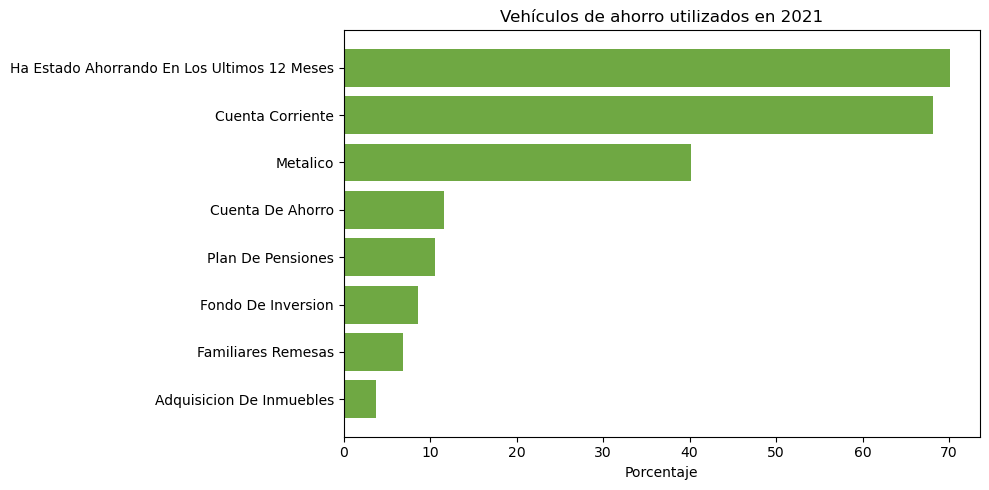

In [34]:
ahorro_general = general[general['concepto'] == 'VEHICULOS DE AHORRO']

ahorro_general = ahorro_general.sort_values('valor', ascending=False)

display(ahorro_general[['indicador', 'valor']])

plt.figure(figsize=(10, 5))
plt.barh(ahorro_general['indicador'], ahorro_general['valor'], color='#6FA843')
plt.gca().invert_yaxis()
plt.title('Vehículos de ahorro utilizados en 2021')
plt.xlabel('Porcentaje')
plt.tight_layout()
plt.show()


**Lectura de negocio**

- Una parte importante de la población declara haber ahorrado en los últimos 12 meses.
- El ahorro se concentra en instrumentos simples, como cuenta corriente o metálico.
- Los productos de inversión o planificación, como fondos y planes de pensiones, tienen menor uso.
- Esto sugiere una oportunidad para convertir ahorro básico en productos de ahorro/inversión sencillos y guiados.


# Análisis 2 — Comportamiento por edad

Ahora revisamos si el comportamiento cambia por grupos de edad. Este análisis ayuda a ajustar segmentos de clientes.


In [35]:
edad = comportamiento[comportamiento['desglose'] == 'EDAD'].copy()

orden_edad = ['Entre 18 y 34', 'Entre 35 y 44', 'Entre 45 y 54', 'Entre 55 y 64', 'Entre 65 y 79']
edad['categoria'] = pd.Categorical(edad['categoria'], categories=orden_edad, ordered=True)

edad[['concepto', 'indicador', 'categoria', 'valor']].head()


,concepto,indicador,categoria,valor
3099,TENENCIA DE PRODUCTOS FINANCIEROS,Cuenta Corriente,Entre 18 y 34,97.550812
3100,TENENCIA DE PRODUCTOS FINANCIEROS,Algun Vehiculo De Ahorro,Entre 18 y 34,29.349688
3101,TENENCIA DE PRODUCTOS FINANCIEROS,Algun Vehiculo De Ahorro (Sin Criptomonedas),Entre 18 y 34,22.113354
3102,TENENCIA DE PRODUCTOS FINANCIEROS,Cuenta De Ahorro,Entre 18 y 34,12.866539
3103,TENENCIA DE PRODUCTOS FINANCIEROS,Plan De Pensiones,Entre 18 y 34,4.819424


## 2.1 Hipotecas por edad

indicador,categoria,Hipoteca
0,Entre 18 y 34,8.174337
1,Entre 35 y 44,27.529591
2,Entre 45 y 54,26.945985
3,Entre 55 y 64,15.066208
4,Entre 65 y 79,7.567250


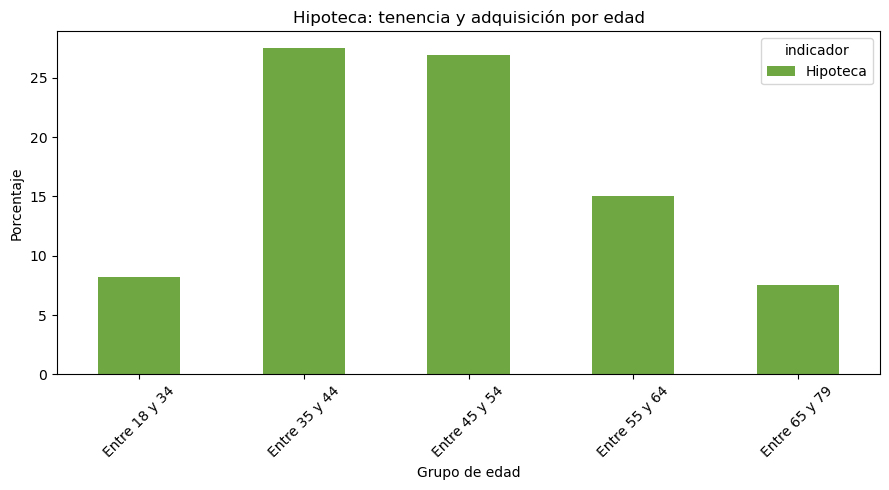

In [36]:
hipoteca_edad = edad[
    edad['elemento'].isin([
        'TENENCIA PRODUCTO_HIPOTECA',
        'ADQUISICION PRODUCTO_HIPOTECA'
    ])
].copy()

pivot_hipoteca = hipoteca_edad.pivot_table(
    index='categoria',
    columns='indicador',
    values='valor',
    aggfunc='mean',
    observed=False
).reset_index()

display(pivot_hipoteca)

pivot_hipoteca.plot(x='categoria', kind='bar', figsize=(9, 5), color=['#6FA843', '#24454F', '#A7C783', '#536B7D'])
plt.title('Hipoteca: tenencia y adquisición por edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Porcentaje')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Conclusión de negocio**

Las hipotecas se concentran principalmente en edades adultas, especialmente entre 35 y 54 años. Esto indica que las ofertas hipotecarias deberían dirigirse sobre todo a perfiles en etapa de compra o consolidación de vivienda.

**Acción recomendada:** reforzar paquetes hipotecarios con seguros, cuenta nómina, asesoramiento y productos familiares asociados.


## 2.2 Préstamos personales por edad

indicador,categoria,Prestamo Personal
0,Entre 18 y 34,15.581197
1,Entre 35 y 44,26.232246
2,Entre 45 y 54,23.377426
3,Entre 55 y 64,19.184296
4,Entre 65 y 79,8.856483


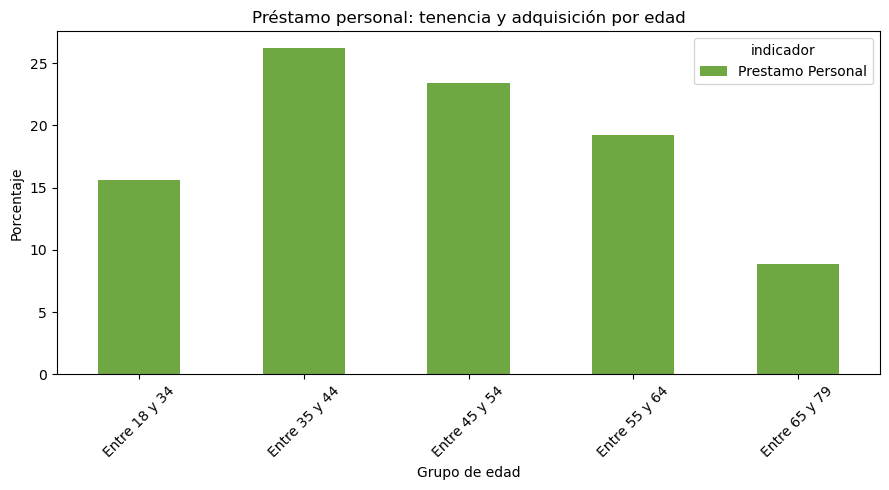

In [37]:
prestamo_edad = edad[
    edad['elemento'].isin([
        'TENENCIA PRODUCTO_PRESTAMO PERSONAL',
        'ADQUISICION PRODUCTO_PRESTAMO PERSONAL'
    ])
].copy()

pivot_prestamo = prestamo_edad.pivot_table(
    index='categoria',
    columns='indicador',
    values='valor',
    aggfunc='mean',
    observed=False
).reset_index()

display(pivot_prestamo)

pivot_prestamo.plot(x='categoria', kind='bar', figsize=(9, 5), color=['#6FA843', '#24454F', '#A7C783', '#536B7D'])
plt.title('Préstamo personal: tenencia y adquisición por edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Porcentaje')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Conclusión de negocio**

El préstamo personal tiene más presencia en edades adultas, donde suele haber más necesidades de financiación: hogar, vehículo, reformas, estudios o consumo familiar.

**Acción recomendada:** diseñar financiación responsable con simuladores, cuotas claras y ofertas segmentadas por etapa vital.


## 2.3 Ahorro por edad

,categoria,valor
5432,Entre 18 y 34,86.933563
5440,Entre 35 y 44,77.321983
5448,Entre 45 y 54,71.065506
5456,Entre 55 y 64,58.902729
5464,Entre 65 y 79,50.350613


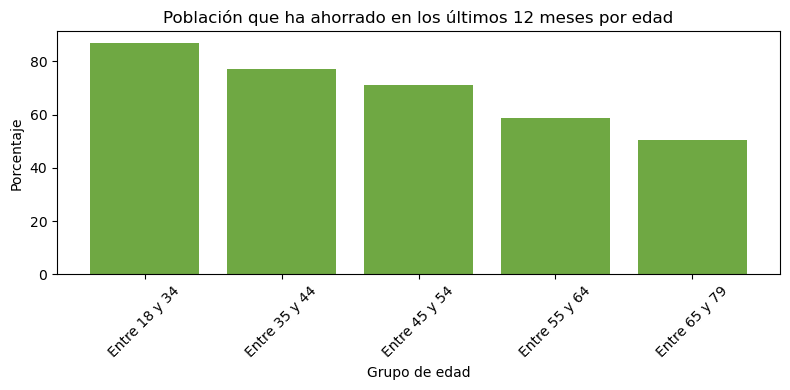

In [38]:
ahorro_edad = edad[
    edad['elemento'] == 'VEHICULOS AHORRO_HA ESTADO AHORRANDO EN LOS ULTIMOS 12 MESES'
].copy()

ahorro_edad = ahorro_edad.sort_values('categoria')

display(ahorro_edad[['categoria', 'valor']])

plt.figure(figsize=(8, 4))
plt.bar(ahorro_edad['categoria'].astype(str), ahorro_edad['valor'], color='#6FA843')
plt.title('Población que ha ahorrado en los últimos 12 meses por edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Porcentaje')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Conclusión de negocio**

El ahorro existe en todos los grupos, pero no siempre se canaliza hacia productos financieros avanzados. Esto abre una oportunidad para transformar ahorro informal o básico en productos bancarios simples.

**Acción recomendada:** crear productos de ahorro automático, cuentas remuneradas, objetivos de ahorro y soluciones digitales fáciles de entender.


# Análisis 3 — Comportamiento por renta

La renta permite entender capacidad de ahorro, contratación de productos y vulnerabilidad económica.


In [39]:
renta = comportamiento[comportamiento['desglose'] == 'RENTA TOTAL DEL HOGAR'].copy()

orden_renta = ['Grupo 1 (baja)', 'Grupo 2', 'Grupo 3', 'Grupo 4 (alta)']
renta['categoria'] = pd.Categorical(renta['categoria'], categories=orden_renta, ordered=True)

renta[['concepto', 'indicador', 'categoria', 'valor']].head()


,concepto,indicador,categoria,valor
3369,TENENCIA DE PRODUCTOS FINANCIEROS,Cuenta Corriente,Grupo 1 (baja),95.096771
3370,TENENCIA DE PRODUCTOS FINANCIEROS,Algun Vehiculo De Ahorro,Grupo 1 (baja),19.453053
3371,TENENCIA DE PRODUCTOS FINANCIEROS,Algun Vehiculo De Ahorro (Sin Criptomonedas),Grupo 1 (baja),17.682873
3372,TENENCIA DE PRODUCTOS FINANCIEROS,Cuenta De Ahorro,Grupo 1 (baja),8.002352
3373,TENENCIA DE PRODUCTOS FINANCIEROS,Plan De Pensiones,Grupo 1 (baja),7.421928


## 3.1 Ahorro por renta

,categoria,valor
5576,Grupo 1 (baja),50.783951
5584,Grupo 2,67.272736
5592,Grupo 3,79.745857
5600,Grupo 4 (alta),89.428902


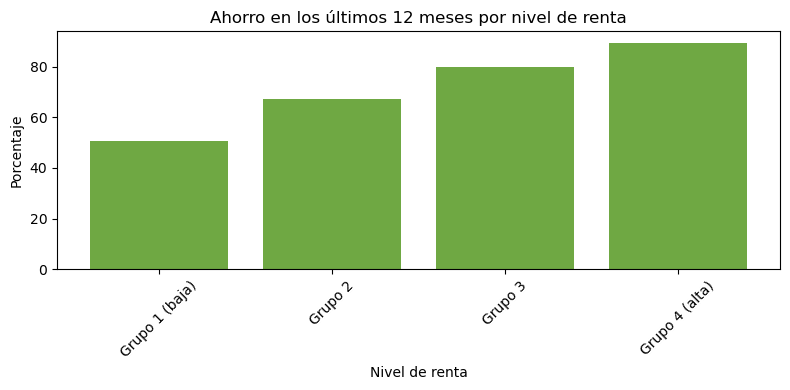

In [40]:
ahorro_renta = renta[
    renta['elemento'] == 'VEHICULOS AHORRO_HA ESTADO AHORRANDO EN LOS ULTIMOS 12 MESES'
].copy()

ahorro_renta = ahorro_renta.sort_values('categoria')

display(ahorro_renta[['categoria', 'valor']])

plt.figure(figsize=(8, 4))
plt.bar(ahorro_renta['categoria'].astype(str), ahorro_renta['valor'], color='#6FA843')
plt.title('Ahorro en los últimos 12 meses por nivel de renta')
plt.xlabel('Nivel de renta')
plt.ylabel('Porcentaje')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Conclusión de negocio**

La capacidad de ahorro aumenta claramente con la renta. Los segmentos de mayor renta son más adecuados para productos de ahorro, inversión y planificación financiera.

**Acción recomendada:** ofrecer fondos, planes, inversión conservadora o asesoramiento patrimonial a segmentos de renta media-alta y alta.


## 3.2 Vulnerabilidad económica por renta

indicador,categoria,Mas De Seis Meses,Menos De Una Semana
0,Grupo 1 (baja),31.307604,13.975793
1,Grupo 2,52.544510,4.697276
2,Grupo 3,69.340622,2.075869
3,Grupo 4 (alta),85.256813,0.792726


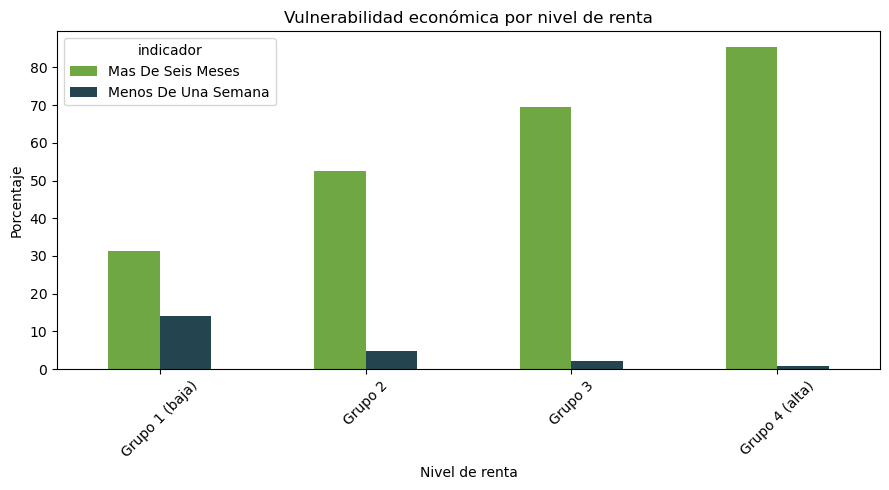

In [41]:
vulnerabilidad_renta = renta[
    renta['elemento'].isin([
        'VULNERABILIDAD ECONOMICA_MENOS DE UNA SEMANA',
        'VULNERABILIDAD ECONOMICA_MAS DE SEIS MESES'
    ])
].copy()

pivot_vulnerabilidad = vulnerabilidad_renta.pivot_table(
    index='categoria',
    columns='indicador',
    values='valor',
    aggfunc='mean',
    observed=False
).reset_index()

display(pivot_vulnerabilidad)

pivot_vulnerabilidad.plot(x='categoria', kind='bar', figsize=(9, 5), color=['#6FA843', '#24454F', '#A7C783', '#536B7D'])
plt.title('Vulnerabilidad económica por nivel de renta')
plt.xlabel('Nivel de renta')
plt.ylabel('Porcentaje')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Conclusión de negocio**

Los hogares de menor renta presentan mayor vulnerabilidad económica, mientras que los de renta alta muestran mayor capacidad para resistir varios meses sin ingresos.

**Acción recomendada:** para rentas bajas, priorizar herramientas de control financiero, microahorro, alertas de gasto y financiación responsable, evitando productos complejos o sobreendeudamiento.


## 3.3 Gastos mayores que ingresos por renta

,categoria,valor
6187,Grupo 1 (baja),42.578419
6194,Grupo 2,25.767412
6201,Grupo 3,17.596970
6208,Grupo 4 (alta),9.623208


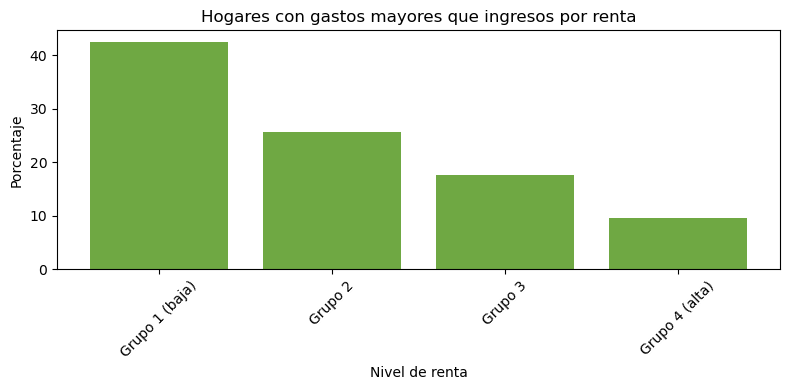

In [42]:
gastos_renta = renta[
    renta['elemento'] == 'GASTOS MAYORES QUE INGRESOS_SUS GASTOS HAN SIDO MAYORES QUE SUS INGRESOS EN LOS ULTIMOS 12 MESES'
].copy()

gastos_renta = gastos_renta.sort_values('categoria')

display(gastos_renta[['categoria', 'valor']])

plt.figure(figsize=(8, 4))
plt.bar(gastos_renta['categoria'].astype(str), gastos_renta['valor'], color='#6FA843')
plt.title('Hogares con gastos mayores que ingresos por renta')
plt.xlabel('Nivel de renta')
plt.ylabel('Porcentaje')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Conclusión de negocio**

Cuando los gastos superan los ingresos, el cliente tiene menor margen para contratar productos financieros complejos. Este patrón es especialmente importante para ajustar la oferta según capacidad económica real.

**Acción recomendada:** crear soluciones de salud financiera, planificación de gastos y productos de bajo riesgo para clientes con menor renta.


# Análisis 4 — Situación laboral

La situación laboral ayuda a detectar perfiles con necesidades financieras distintas: trabajadores activos, desempleados, jubilados, estudiantes, etc.


In [43]:
laboral = comportamiento[comportamiento['desglose'] == 'SITUACION LABORAL'].copy()

laboral[['concepto', 'indicador', 'categoria', 'valor']].head()


,concepto,indicador,categoria,valor
3249,TENENCIA DE PRODUCTOS FINANCIEROS,Cuenta Corriente,Cuenta propia,99.053154
3250,TENENCIA DE PRODUCTOS FINANCIEROS,Algun Vehiculo De Ahorro,Cuenta propia,53.964294
3251,TENENCIA DE PRODUCTOS FINANCIEROS,Algun Vehiculo De Ahorro (Sin Criptomonedas),Cuenta propia,51.898911
3252,TENENCIA DE PRODUCTOS FINANCIEROS,Cuenta De Ahorro,Cuenta propia,20.818224
3253,TENENCIA DE PRODUCTOS FINANCIEROS,Plan De Pensiones,Cuenta propia,33.825428


## 4.1 Ahorro por situación laboral

,categoria,valor
5520,Cuenta ajena,79.199036
5512,Cuenta propia,77.466080
5544,Otros inactivos,61.493313
5528,Desempleo,58.480942
5536,Jubilacion,54.688923


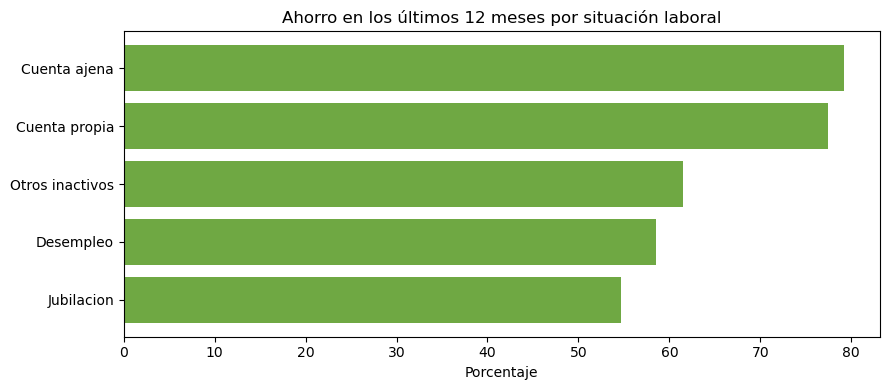

In [44]:
ahorro_laboral = laboral[
    laboral['elemento'] == 'VEHICULOS AHORRO_HA ESTADO AHORRANDO EN LOS ULTIMOS 12 MESES'
].copy()

ahorro_laboral = ahorro_laboral.sort_values('valor', ascending=False)

display(ahorro_laboral[['categoria', 'valor']])

plt.figure(figsize=(9, 4))
plt.barh(ahorro_laboral['categoria'], ahorro_laboral['valor'], color='#6FA843')
plt.gca().invert_yaxis()
plt.title('Ahorro en los últimos 12 meses por situación laboral')
plt.xlabel('Porcentaje')
plt.tight_layout()
plt.show()


## 4.2 Gastos mayores que ingresos por situación laboral

,categoria,valor
6145,Desempleo,43.080044
6159,Otros inactivos,26.434746
6131,Cuenta propia,25.288239
6138,Cuenta ajena,22.453306
6152,Jubilacion,19.997433


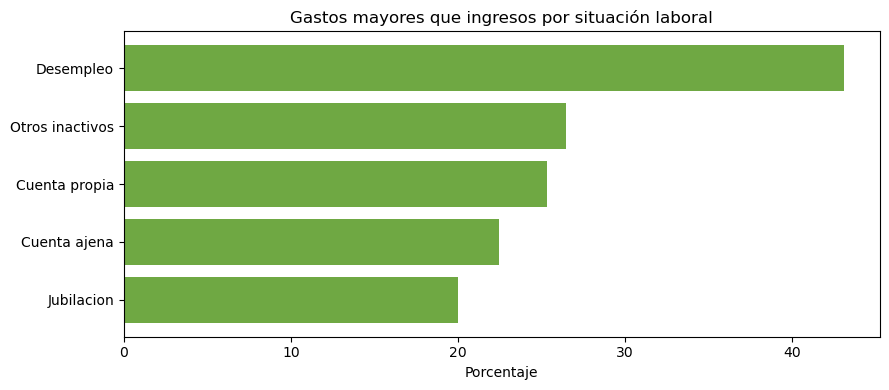

In [45]:
gastos_laboral = laboral[
    laboral['elemento'] == 'GASTOS MAYORES QUE INGRESOS_SUS GASTOS HAN SIDO MAYORES QUE SUS INGRESOS EN LOS ULTIMOS 12 MESES'
].copy()

gastos_laboral = gastos_laboral.sort_values('valor', ascending=False)

display(gastos_laboral[['categoria', 'valor']])

plt.figure(figsize=(9, 4))
plt.barh(gastos_laboral['categoria'], gastos_laboral['valor'], color='#6FA843')
plt.gca().invert_yaxis()
plt.title('Gastos mayores que ingresos por situación laboral')
plt.xlabel('Porcentaje')
plt.tight_layout()
plt.show()


**Conclusión de negocio**

La situación laboral permite diferenciar ofertas. No todos los clientes necesitan los mismos productos: trabajadores activos pueden necesitar crédito, hipoteca o ahorro programado; jubilados pueden necesitar seguridad y planificación; desempleados o perfiles vulnerables necesitan control financiero y productos de bajo riesgo.


# Conclusiones finales y recomendaciones de negocio

El análisis del comportamiento financiero de la ECF 2021 muestra que la población española utiliza de forma generalizada productos financieros básicos, especialmente cuentas corrientes y tarjetas. Estos productos funcionan como punto de entrada a la relación bancaria, pero por sí solos no representan una gran oportunidad diferencial.

A partir del análisis por productos, edad, renta y situación laboral, se identifican varias oportunidades para ajustar la estrategia de negocio.

## 1. Productos básicos como puerta de entrada

La cuenta corriente y la tarjeta de crédito tienen una presencia elevada en la población. Esto indica que la estrategia comercial puede apoyarse en estos productos para ofrecer servicios adicionales más personalizados.

**Recomendación:** utilizar productos básicos como base para venta cruzada, ofreciendo paquetes adaptados según edad, renta y situación laboral.

## 2. Hipotecas y préstamos en perfiles adultos

Las hipotecas y los préstamos personales se concentran especialmente en edades adultas, donde suelen existir necesidades de financiación asociadas a vivienda, familia, reformas o consumo.

**Recomendación:** reforzar ofertas para adultos de 35 a 54 años mediante paquetes hipotecarios, seguros asociados, cuenta nómina, asesoramiento y financiación responsable.

## 3. Oportunidad en ahorro e inversión

El análisis muestra que existe comportamiento de ahorro, pero no siempre se canaliza hacia productos financieros más planificados o rentables. Productos como fondos de inversión o planes tienen menor penetración en algunos segmentos.

**Recomendación:** crear soluciones de ahorro automático, cuentas remuneradas, objetivos de ahorro y productos de inversión conservadora con acompañamiento sencillo.

## 4. Segmentación por renta

La renta marca diferencias claras en la capacidad de ahorro, inversión y vulnerabilidad económica. Los grupos de mayor renta presentan más potencial para productos de planificación financiera, mientras que los grupos de menor renta requieren soluciones más prudentes.

**Recomendación:** ofrecer fondos, planes y asesoramiento patrimonial a rentas medias-altas y altas; para rentas bajas, priorizar control de gastos, microahorro, educación financiera y crédito responsable.

## 5. Vulnerabilidad económica y salud financiera

Los indicadores de gastos superiores a ingresos y vulnerabilidad económica muestran que algunos perfiles tienen menor margen para asumir deuda o contratar productos complejos.

**Recomendación:** desarrollar herramientas de salud financiera, alertas de gasto, planificación mensual, refinanciación responsable y productos simples de bajo riesgo.

## Conclusión general

Sí es recomendable ajustar la estrategia de negocio. Los datos de comportamiento financiero de 2021 indican que la oferta bancaria no debería ser única para todos los clientes. La estrategia debería diferenciar entre perfiles con necesidades de financiación, perfiles con capacidad de ahorro e inversión, y perfiles vulnerables que necesitan acompañamiento, control financiero y productos sencillos.